### SAC Eval: B747 Step-Response (ImprovedB747Env)

This notebook:
- **Finds the latest SAC checkpoint** (from `./sac_b747_vec64_step_best` by default)
- **Loads the agent** via `SAC.from_pretrained(...)`
- Runs **1 deterministic episode** and plots **theta vs ref(theta)**
- Runs **N episodes** and prints statistics (return, overshoot, settling)

Launch TensorBoard for training rewards:

```bash
tensorboard --logdir runs/sac_b747_vec64_step
```

In [1]:
# Imports
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import numpy as np
import torch

from tensoraerospace.agent.sac.sac import SAC
from tensoraerospace.envs.b747 import ImprovedB747Env
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period

# Plotting
import matplotlib.pyplot as plt

# Device
DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)
print("Using device:", DEVICE)

np.random.seed(1)
_ = torch.manual_seed(1)



2026-01-03 03:13:49.141918: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-03 03:13:49.141950: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-03 03:13:49.142758: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-03 03:13:49.147682: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-03 03:13:49.936904: W tensorflow/compiler/tf2

Using device: cuda


In [2]:
# Pick checkpoint

DEFAULT_BEST_DIR = Path("./sac_b747_vec64_step_1deg_t5_best")

# Option A: set explicit path to a saved SAC folder (contains config.json)
CHECKPOINT_DIR: Optional[Path] = None

# Option B: auto-pick latest folder under DEFAULT_BEST_DIR

def pick_latest_checkpoint_dir(root: Path) -> Path:
    root = Path(root)
    if root.is_file() and root.name == "config.json":
        return root.parent
    if root.is_dir() and (root / "config.json").exists():
        return root

    if not root.exists() or not root.is_dir():
        raise FileNotFoundError(f"Checkpoint root not found: {root.resolve()}")

    candidates = [p for p in root.iterdir() if p.is_dir() and (p / "config.json").exists()]
    if not candidates:
        raise FileNotFoundError(
            f"No checkpoints found under: {root.resolve()} (expected */config.json)"
        )

    return max(candidates, key=lambda p: p.stat().st_mtime)


ckpt_dir = CHECKPOINT_DIR or pick_latest_checkpoint_dir(DEFAULT_BEST_DIR)
print("Checkpoint dir:", ckpt_dir.resolve())



Checkpoint dir: /home/mr8bit/Projects/TensorAeroSpace/example/comparison/sac_b747_vec64_step_1deg_t5_best/Jan02_21-56-15_SAC


In [3]:
# Load agent

def move_agent_to(agent: SAC, device: torch.device) -> SAC:
    device = torch.device(device)
    agent.device = device
    agent.critic = agent.critic.to(device)
    agent.critic_target = agent.critic_target.to(device)
    agent.policy = agent.policy.to(device)
    if getattr(agent, "automatic_entropy_tuning", False) and hasattr(agent, "log_alpha"):
        try:
            agent.log_alpha.data = agent.log_alpha.data.to(device)
        except Exception:
            pass
    return agent


agent = SAC.from_pretrained(str(ckpt_dir))
agent = move_agent_to(agent, DEVICE)

print("Loaded SAC. device:", agent.device)
print("Policy type:", getattr(agent, "policy_type", None))
print("Auto entropy:", getattr(agent, "automatic_entropy_tuning", None))
print("Alpha:", getattr(agent, "alpha", None))



Loaded SAC. device: cuda
Policy type: Gaussian
Auto entropy: False
Alpha: 0.2


Episode return: -12.027557868225674
RMSE(deg): 0.6492979152024398
Final error (deg): -0.71944528586371
Max abs error (deg): 0.995244346029503


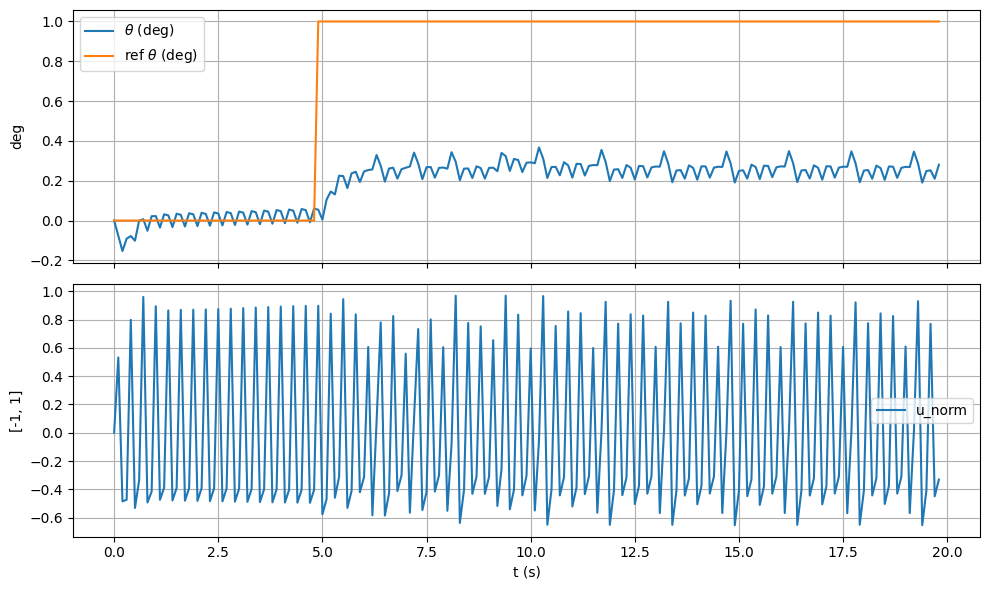

settled: False
settle_time_s: -1.0
max_overshoot_ratio (episode): 0.0


In [4]:
# Build eval env + run one episode (deterministic)

@dataclass
class StepSpec:
    amplitude_deg: float = 1.0
    step_time_sec: float = 5.0


def make_step_reference(tp_sec: np.ndarray, spec: StepSpec) -> np.ndarray:
    tp_sec = np.asarray(tp_sec, dtype=np.float32)
    ref = np.zeros_like(tp_sec, dtype=np.float32)
    ref[tp_sec >= float(spec.step_time_sec)] = np.deg2rad(float(spec.amplitude_deg))
    return ref.reshape(1, -1)


# Time base (same as training)
dt = 0.1
tp = generate_time_period(tn=20, dt=dt)
tps = convert_tp_to_sec_tp(tp, dt=dt)
number_time_steps = len(tp)

spec = StepSpec(amplitude_deg=1.0, step_time_sec=5.0)

env = ImprovedB747Env(
    initial_state=np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32),
    reference_signal=make_step_reference(tps, spec),
    number_time_steps=number_time_steps,
    dt=dt,
    initial_elevator_deg=0.0,
    reward_mode="step_response",
)

obs, _ = env.reset(seed=1)

# Rollout
theta = []
target = []
u = []
rewards = []
infos = []

terminated = False
truncated = False
while not (terminated or truncated):
    # env obs is already normalized to [-1, 1]
    action = agent.select_action(np.asarray(obs, dtype=np.float32), evaluate=True)
    obs, r, terminated, truncated, info = env.step(action)

    rewards.append(float(r))
    infos.append(info)
    theta.append(float(info.get("theta_rad", 0.0)))
    target.append(float(info.get("target_theta_rad", 0.0)))
    u.append(float(info.get("u_norm", 0.0)))

ret = float(np.sum(rewards))
err_deg = np.rad2deg(np.asarray(theta) - np.asarray(target))
rmse_deg = float(np.sqrt(np.mean(err_deg**2))) if len(err_deg) else float('nan')
final_err_deg = float(err_deg[-1]) if len(err_deg) else float('nan')
max_abs_err_deg = float(np.max(np.abs(err_deg))) if len(err_deg) else float('nan')

print("Episode return:", ret)
print("RMSE(deg):", rmse_deg)
print("Final error (deg):", final_err_deg)
print("Max abs error (deg):", max_abs_err_deg)

# Plot
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(tps[: len(theta)], np.rad2deg(theta), label=r"$\theta$ (deg)")
ax[0].plot(tps[: len(target)], np.rad2deg(target), label=r"ref $\theta$ (deg)")
ax[0].set_ylabel("deg")
ax[0].grid(True)
ax[0].legend()

ax[1].plot(tps[: len(u)], u, label="u_norm")
ax[1].set_xlabel("t (s)")
ax[1].set_ylabel("[-1, 1]")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

# Step metrics from info (last step)
if infos:
    last = infos[-1]
    print("settled:", last.get("settled"))
    print("settle_time_s:", last.get("settle_time_s"))
    print("max_overshoot_ratio (episode):", max(i.get("overshoot_ratio", 0.0) for i in infos))



In [5]:
# Batch eval: randomized steps

@dataclass
class StepRand:
    # Default eval is the *exact* target task: 1deg step at 5s
    amplitude_deg_range: tuple[float, float] = (1.0, 1.0)
    min_abs_amplitude_deg: float = 1.0
    step_time_sec_range: tuple[float, float] = (5.0, 5.0)


def sample_step_spec(rng: np.random.Generator, cfg: StepRand) -> StepSpec:
    a0, a1 = cfg.amplitude_deg_range
    amp = float(rng.uniform(a0, a1))
    if abs(amp) < float(cfg.min_abs_amplitude_deg):
        amp = float(np.sign(amp) if amp != 0.0 else 1.0) * float(cfg.min_abs_amplitude_deg)

    t0, t1 = cfg.step_time_sec_range
    st = float(rng.uniform(t0, t1))
    return StepSpec(amplitude_deg=amp, step_time_sec=st)


def eval_n_episodes(
    agent: SAC,
    *,
    n_episodes: int = 50,
    seed: int = 123,
    reward_mode: str = "step_response",
) -> dict:
    rng = np.random.default_rng(seed)
    cfg = StepRand()

    returns = []
    overshoot_max = []
    settle_time = []
    rmse_deg_list = []
    terminated_count = 0

    for ep in range(int(n_episodes)):
        spec = sample_step_spec(rng, cfg)
        env = ImprovedB747Env(
            initial_state=np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32),
            reference_signal=make_step_reference(tps, spec),
            number_time_steps=number_time_steps,
            dt=dt,
            initial_elevator_deg=0.0,
            reward_mode=reward_mode,
        )
        obs, _ = env.reset(seed=int(seed) + ep)

        ep_ret = 0.0
        infos = []
        theta = []
        target = []
        terminated = False
        truncated = False
        while not (terminated or truncated):
            a = agent.select_action(np.asarray(obs, dtype=np.float32), evaluate=True)
            obs, r, terminated, truncated, info = env.step(a)
            ep_ret += float(r)
            infos.append(info)
            theta.append(float(info.get("theta_rad", 0.0)))
            target.append(float(info.get("target_theta_rad", 0.0)))

        returns.append(ep_ret)
        overshoot_max.append(max(i.get("overshoot_ratio", 0.0) for i in infos) if infos else 0.0)

        err_deg = np.rad2deg(np.asarray(theta) - np.asarray(target))
        rmse_deg_list.append(float(np.sqrt(np.mean(err_deg**2))) if len(err_deg) else float('nan'))

        st = -1.0
        for i in infos:
            if bool(i.get("settled", False)):
                st = float(i.get("settle_time_s", -1.0))
        settle_time.append(st)

        if terminated:
            terminated_count += 1

    returns_np = np.asarray(returns, dtype=np.float32)
    overshoot_np = np.asarray(overshoot_max, dtype=np.float32)
    settle_np = np.asarray(settle_time, dtype=np.float32)
    rmse_np = np.asarray(rmse_deg_list, dtype=np.float32)

    return {
        "n": int(n_episodes),
        "return_mean": float(np.mean(returns_np)),
        "return_std": float(np.std(returns_np)),
        "return_p10": float(np.quantile(returns_np, 0.10)),
        "return_p50": float(np.quantile(returns_np, 0.50)),
        "return_p90": float(np.quantile(returns_np, 0.90)),
        "overshoot_mean": float(np.mean(overshoot_np)),
        "overshoot_p90": float(np.quantile(overshoot_np, 0.90)),
        "rmse_deg_mean": float(np.mean(rmse_np)),
        "rmse_deg_p90": float(np.quantile(rmse_np, 0.90)),
        "settle_time_mean": float(np.mean(settle_np[settle_np >= 0])) if np.any(settle_np >= 0) else float('nan'),
        "settled_frac": float(np.mean((settle_np >= 0).astype(np.float32))),
        "terminated_frac": float(terminated_count / float(n_episodes)),
    }


stats = eval_n_episodes(agent, n_episodes=50, seed=123)
for k, v in stats.items():
    print(f"{k}: {v}")



n: 50
return_mean: -12.027560234069824
return_std: 1.9073486328125e-06
return_p10: -12.027558326721191
return_p50: -12.027558326721191
return_p90: -12.027558326721191
overshoot_mean: 0.0
overshoot_p90: 0.0
rmse_deg_mean: 0.6492979526519775
rmse_deg_p90: 0.6492978930473328
settle_time_mean: nan
settled_frac: 0.0
terminated_frac: 0.0
